# Transport Physics: Landauer-Style Chain Transmission

This notebook computes a simple coherent-transport transmission curve for a finite chain coupled to left and right leads. The solver uses Green's functions and compares exact inverses with inverse-polynomial approximations of the positive Hermitian denominator.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite tight-binding device coupled to left and right leads.

**QSVT implementation.** It uses polynomial resolvent approximations inside a Landauer transmission calculation. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Direct dense Green's functions provide the reference curve. For larger mesoscopic devices, QSVT resolvent primitives are relevant when the device Hamiltonian is sparse or block encoded and only transmission observables are needed.


## Variable definitions

- `n`: number of sites in the transport chain.
- `H`: tight-binding device Hamiltonian.
- `Gamma_L`, `Gamma_R`: left and right lead coupling strengths.
- `eta`: imaginary broadening used in the Green's function.
- `evals`: eigenvalues of `H`.
- `scale`: spectral radius used for rescaling.
- `A`: rescaled Hamiltonian.
- `energies`: transport-energy grid.
- `T_exact`, `T_poly`: exact and polynomial transmission curves.
- `E`: current transport energy in the loop.
- `G`: exact retarded Green's-function matrix.
- `real_coeffs`, `imag_coeffs`: polynomial coefficients for the resolvent components.
- `G_approx`: polynomial Green's-function approximation.
- `curve_error`: relative error between transmission curves.
- `sites`, `fig`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from qsvt.matrix_functions import design_resolvent_polynomials

n = 6
H = tight_binding_chain(n)

Gamma_L = np.zeros((n, n))
Gamma_L[0, 0] = 0.55
Gamma_R = np.zeros((n, n))
Gamma_R[-1, -1] = 0.55
eta = 0.45 * (Gamma_L[0, 0] + Gamma_R[-1, -1]) / 2.0
evals, _ = eigh_hermitian(H)
scale = np.max(np.abs(evals))
A = H / scale

energies = np.linspace(-2.4, 2.4, 90)
T_exact = []
T_poly = []
for E in energies:
    G = np.linalg.inv((E + 1j * eta) * np.eye(n) - H)
    T_exact.append(np.real(np.trace(Gamma_L @ G @ Gamma_R @ G.conj().T)))

    real_coeffs, imag_coeffs = design_resolvent_polynomials(
        omega=E, eta=eta, scale=scale, degree=42
    )
    G_approx = apply_polynomial_to_hermitian(
        A, real_coeffs
    ) + 1j * apply_polynomial_to_hermitian(A, imag_coeffs)
    T_poly.append(np.real(np.trace(Gamma_L @ G_approx @ Gamma_R @ G_approx.conj().T)))

curve_error = np.linalg.norm(np.array(T_poly) - np.array(T_exact)) / np.linalg.norm(
    T_exact
)
print(f"Curve Error: {curve_error}")

Curve Error: 0.00625639231073604


## Transport setup schematic

The Landauer response couples a finite device chain to left and right reservoirs through endpoint broadenings.


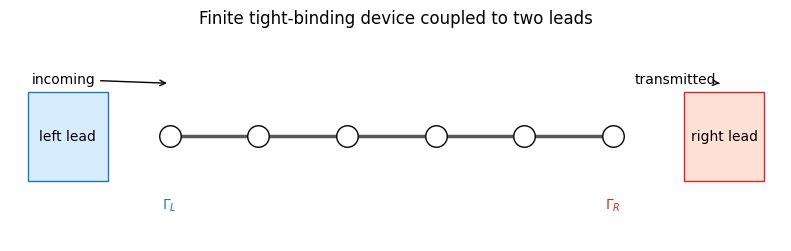

In [2]:
fig, ax = plt.subplots(figsize=(7.8, 2.4), constrained_layout=True)

sites = np.arange(n)
ax.add_patch(
    plt.Rectangle((-1.6, -0.32), 0.9, 0.64, facecolor="#d8ecff", edgecolor="tab:blue")
)
ax.add_patch(
    plt.Rectangle((n - 0.2, -0.32), 0.9, 0.64, facecolor="#ffe0d4", edgecolor="tab:red")
)
ax.text(-1.15, 0, "left lead", ha="center", va="center")
ax.text(n + 0.25, 0, "right lead", ha="center", va="center")
for site in range(n - 1):
    ax.plot([site, site + 1], [0, 0], color="0.35", linewidth=2.5)
ax.scatter(sites, np.zeros(n), s=240, color="white", edgecolor="black", zorder=3)
ax.annotate(
    "incoming",
    xy=(0, 0.38),
    xytext=(-1.2, 0.38),
    arrowprops={"arrowstyle": "->"},
    ha="center",
)
ax.annotate(
    "transmitted",
    xy=(n + 0.2, 0.38),
    xytext=(n - 0.3, 0.38),
    arrowprops={"arrowstyle": "->"},
    ha="center",
)
ax.text(0, -0.52, r"$\Gamma_L$", ha="center", color="tab:blue")
ax.text(n - 1, -0.52, r"$\Gamma_R$", ha="center", color="tab:red")
ax.set_title("Finite tight-binding device coupled to two leads")
ax.set_xlim(-1.8, n + 0.9)
ax.set_ylim(-0.75, 0.75)
ax.axis("off")
plt.show()

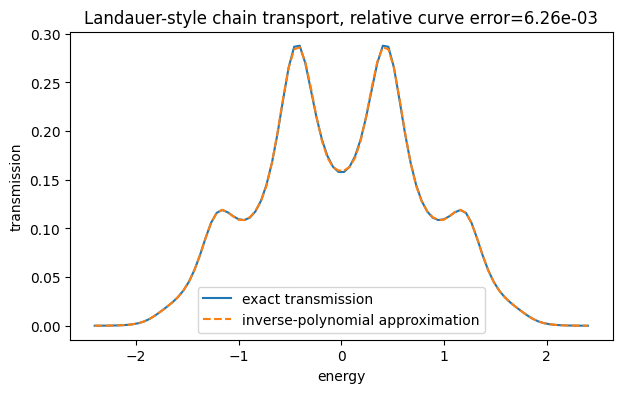

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(energies, T_exact, label="exact transmission")
plt.plot(energies, T_poly, "--", label="inverse-polynomial approximation")
plt.xlabel("energy")
plt.ylabel("transmission")
plt.title(f"Landauer-style chain transport, relative curve error={curve_error:.2e}")
plt.legend()
plt.show()